In [1]:
pip install tensorflow matplotlib seaborn scikit-learn numpy pillow


Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('Libraries imported successfully!')

TensorFlow version: 2.20.0
Libraries imported successfully!


In [2]:
DATASET_DIR =  "PlantVillage"          # folder name
IMAGE_SIZE  = 256                     # resize to 256x256
BATCH_SIZE  = 32
EPOCHS      = 15
CLASSES     = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy"
]
CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]
NUM_CLASSES = len(CLASSES)
 
# Verify dataset exists
print("\nChecking dataset folders...")
all_ok = True
for c in CLASSES:
    path = os.path.join(DATASET_DIR, c)
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"  OK  {c} : {count} images")
    else:
        print(f"  NOT FOUND : {path}")
        all_ok = False
 
if all_ok:
    print("\nDataset ready! Proceed to next cell.")
else:
    print("\nFix missing folders before running further.")


Checking dataset folders...
  OK  Potato___Early_blight : 1000 images
  OK  Potato___Late_blight : 1000 images
  OK  Potato___healthy : 152 images

Dataset ready! Proceed to next cell.


In [3]:
import os
for root, dirs, files in os.walk("PlantVillage"):
    print(root)
    break
for root, dirs, files in os.walk("PlantVillage"):
    for d in dirs:
        print(os.path.join(root, d))

PlantVillage
PlantVillage\Pepper__bell___Bacterial_spot
PlantVillage\Pepper__bell___healthy
PlantVillage\Potato___Early_blight
PlantVillage\Potato___healthy
PlantVillage\Potato___Late_blight
PlantVillage\Tomato_Bacterial_spot
PlantVillage\Tomato_Early_blight
PlantVillage\Tomato_Late_blight
PlantVillage\Tomato_Leaf_Mold
PlantVillage\Tomato_Septoria_leaf_spot
PlantVillage\Tomato_Spider_mites_Two_spotted_spider_mite
PlantVillage\Tomato__Target_Spot


In [4]:
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    validation_split  = 0.2,
    rotation_range    = 15,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    horizontal_flip   = True,
    zoom_range        = 0.1
)
 
# Validation: only rescale, no augmentation
val_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.2
)
 
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size  = BATCH_SIZE,
    classes     = CLASSES,
    class_mode  = "categorical",
    subset      = "training",
    seed        = 42
)
 
val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size  = BATCH_SIZE,
    classes     = CLASSES,
    class_mode  = "categorical",
    subset      = "validation",
    seed        = 42
)
 
print(f"\nTraining samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")
 

Found 1722 images belonging to 3 classes.
Found 430 images belonging to 3 classes.

Training samples   : 1722
Validation samples : 430


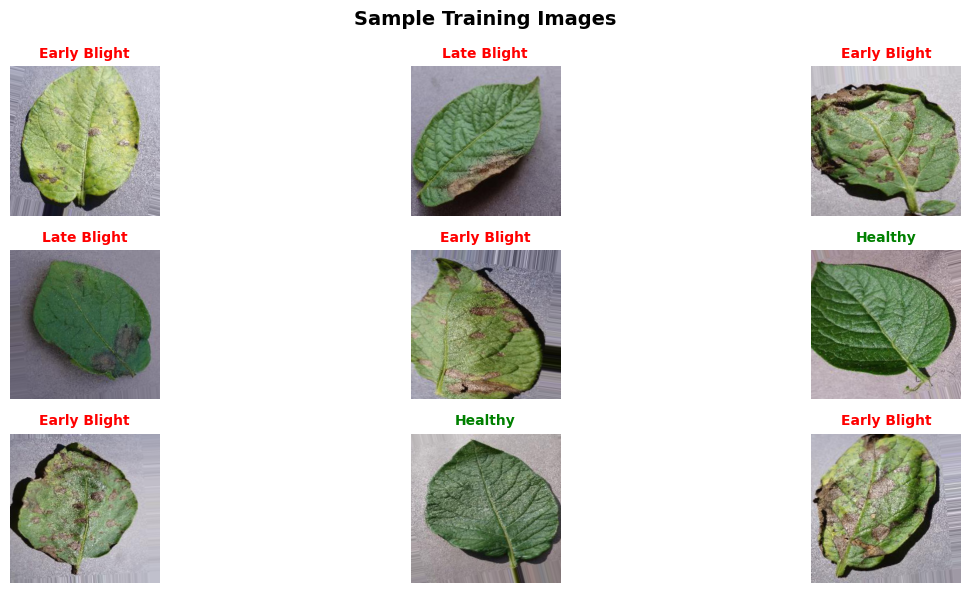

Saved: sample_images.png


In [5]:
images, labels = next(train_generator)
 
plt.figure(figsize=(14, 6))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    label_idx = np.argmax(labels[i])
    color = "green" if CLASS_NAMES[label_idx] == "Healthy" else "red"
    plt.title(CLASS_NAMES[label_idx], fontsize=10,
              color=color, fontweight="bold")
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sample_images.png")

In [6]:
def build_cnn_model(input_shape=(256, 256, 3), num_classes=3):
    model = models.Sequential([
 
        # Block 1 — learns basic edges & colors
        layers.Conv2D(32, (3,3), activation="relu",
                      padding="same", input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
 
        # Block 2 — learns shapes & textures
        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
 
        # Block 3 — learns disease patterns
        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
 
        # Block 4 — learns complex features
        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
 
        # Fully Connected
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),          # prevent overfitting
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")   # output: 3 classes
    ])
    return model
 
model = build_cnn_model()
model.summary()
print(f"\nTotal Parameters: {model.count_params():,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256, 256, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128, 128, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64, 64, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32, 32, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      16,777,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,201,091 (65.62 MB)

 Trainable params: 17,200,131 (65.61 MB)

 Non-trainable params: 960 (3.75 KB)


Total Parameters: 17,201,091


In [7]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)
print("Model compiled!")
 

Model compiled!


In [8]:
callbacks = [
    # Stop if no improvement for 5 epochs
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=5,
        restore_best_weights=True, verbose=1
    ),
    # Reduce learning rate if model is stuck
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    # Save best model automatically
    keras.callbacks.ModelCheckpoint(
        "best_potato_model.h5",
        monitor="val_accuracy",
        save_best_only=True, verbose=1
    )
]
 
print("Training started... (15-30 mins on CPU, be patient!)")
history = model.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = val_generator,
    callbacks       = callbacks,
    verbose         = 1
)
print("Training complete!")
 
 

Training started... (15-30 mins on CPU, be patient!)
Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7456 - loss: 5.0052
Epoch 1: val_accuracy improved from None to 0.46512, saving model to best_potato_model.h5


54/54 ━━━━━━━━━━━━━━━━━━━━ 297s 5s/step - accuracy: 0.8031 - loss: 4.4221 - val_accuracy: 0.4651 - val_loss: 28.5186 - learning_rate: 0.0010
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9011 - loss: 2.4377
Epoch 2: val_accuracy did not improve from 0.46512
54/54 ━━━━━━━━━━━━━━━━━━━━ 290s 5s/step - accuracy: 0.9013 - loss: 2.5592 - val_accuracy: 0.4651 - val_loss: 41.6264 - learning_rate: 0.0010
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8898 - loss: 2.9415
Epoch 3: val_accuracy did not improve from 0.46512
54/54 ━━━━━━━━━━━━━━━━━━━━ 283s 5s/step - accuracy: 0.8943 - loss: 2.6243 - val_accuracy: 0.4651 - val_loss: 36.7127 - learning_rate: 0.0010
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9288 - loss: 1.7381
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.46512
54/54 ━━━━━━━━━━━━━━━━━━━━ 293s 5s/step - accuracy: 0.9158 - loss: 1.7164 - val_accuracy: 0.4651 -

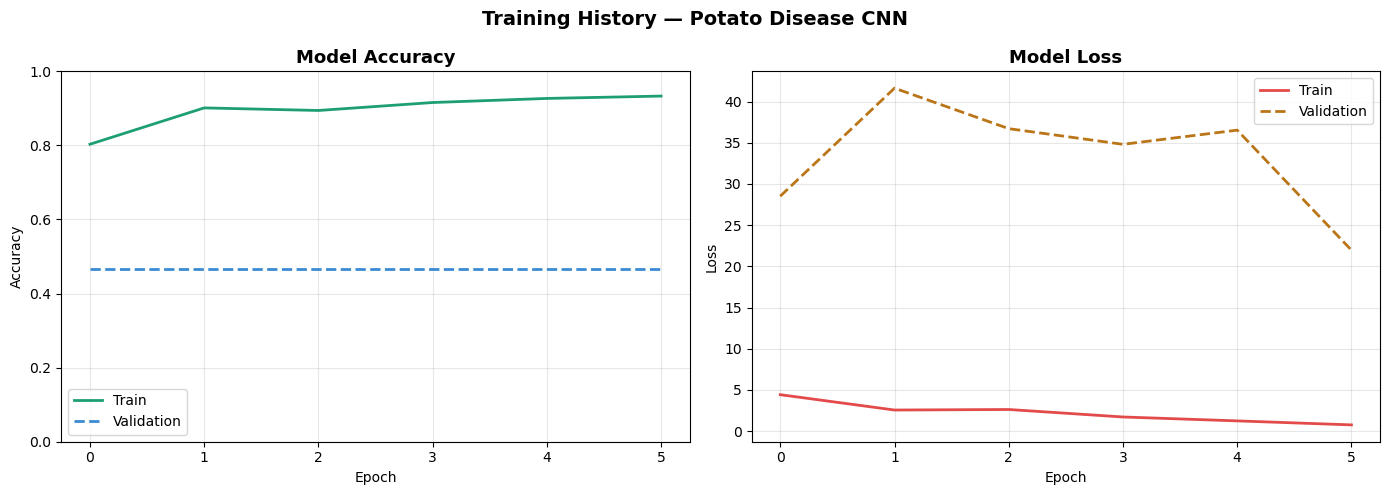

Saved: training_history.png


In [9]:

# ── CELL 9 : Plot Accuracy & Loss ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Accuracy
axes[0].plot(history.history["accuracy"],
             label="Train", color="#1D9E75", linewidth=2)
axes[0].plot(history.history["val_accuracy"],
             label="Validation", color="#3B8BD4",
             linewidth=2, linestyle="--")
axes[0].set_title("Model Accuracy", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])
 
# Loss
axes[1].plot(history.history["loss"],
             label="Train", color="#E24B4A", linewidth=2)
axes[1].plot(history.history["val_loss"],
             label="Validation", color="#BA7517",
             linewidth=2, linestyle="--")
axes[1].set_title("Model Loss", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.suptitle("Training History — Potato Disease CNN",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_history.png")

Validation Accuracy : 46.51%
Validation Loss     : 28.5186
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 655ms/step

Classification Report:
              precision    recall  f1-score   support

Early Blight       0.00      0.00      0.00       200
 Late Blight       0.47      1.00      0.63       200
     Healthy       0.00      0.00      0.00        30

    accuracy                           0.47       430
   macro avg       0.16      0.33      0.21       430
weighted avg       0.22      0.47      0.30       430



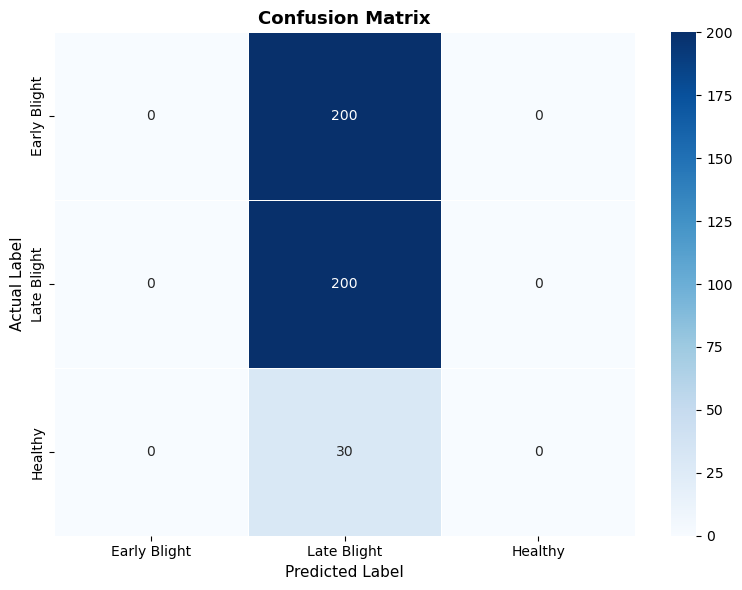

Saved: confusion_matrix.png


In [11]:
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"Validation Accuracy : {val_acc*100:.2f}%")
print(f"Validation Loss     : {val_loss:.4f}")
val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = val_generator.classes
 
# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
 
# Confusion Matrix heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title("Confusion Matrix", fontsize=13, fontweight="bold")
plt.ylabel("Actual Label",    fontsize=11)
plt.xlabel("Predicted Label", fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")
 

In [14]:
def predict_disease(img_path):
    """
    Predict disease from a single potato leaf image.
    Usage: predict_disease("your_potato_image.jpg")
    """
    img       = keras_image.load_img(img_path,
                    target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
 
    preds           = model.predict(img_array, verbose=0)[0]
    predicted_class = CLASS_NAMES[np.argmax(preds)]
    confidence      = np.max(preds) * 100
 
    color = "green" if predicted_class == "Healthy" else "red"
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(
        f"Prediction : {predicted_class}\nConfidence : {confidence:.1f}%",
        fontsize=12, fontweight="bold", color=color
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()
 
    print(f"\nDisease    : {predicted_class}")
    print(f"Confidence : {confidence:.1f}%")
    print("All class probabilities:")
    for i, name in enumerate(CLASS_NAMES):
        bar = "#" * int(preds[i] * 30)
        print(f"  {name:<15} {preds[i]*100:5.1f}%  {bar}")
 
    return predicted_class, confidence
 
# HOW TO USE:
# 1. Put a potato leaf image in the same folder
# 2. Call: predict_disease("leaf.jpg")
print("predict_disease() is ready!")
print('Usage: predict_disease("—Pngtree—green leaf for element_14904901.jpg")')
 

predict_disease() is ready!
Usage: predict_disease("—Pngtree—green leaf for element_14904901.jpg")


In [13]:
model.save("potato_disease_cnn_final.h5")
print("Model saved: potato_disease_cnn_final.h5")
 
print("\n" + "="*52)
print("      PROJECT SUMMARY — NEMI BHATT")
print("="*52)
print(f"  Project   : Potato Disease Detection CNN")
print(f"  Model     : Custom CNN (4 Conv Blocks)")
print(f"  Dataset   : PlantVillage (Kaggle)")
print(f"  Classes   : Early Blight | Late Blight | Healthy")
print(f"  Accuracy  : {val_acc*100:.2f}%")
print(f"  Framework : TensorFlow {tf.__version__} + Keras")
print("="*52)
print("\nFiles saved in your folder:")
print("  - best_potato_model.h5      (best weights)")
print("  - potato_disease_cnn_final.h5  (final model)")
print("  - training_history.png      (accuracy/loss graph)")
print("  - confusion_matrix.png      (evaluation chart)")
print("  - sample_images.png         (dataset preview)")
 





Model saved: potato_disease_cnn_final.h5

      PROJECT SUMMARY — NEMI BHATT
  Project   : Potato Disease Detection CNN
  Model     : Custom CNN (4 Conv Blocks)
  Dataset   : PlantVillage (Kaggle)
  Classes   : Early Blight | Late Blight | Healthy
  Accuracy  : 46.51%
  Framework : TensorFlow 2.20.0 + Keras

Files saved in your folder:
  - best_potato_model.h5      (best weights)
  - potato_disease_cnn_final.h5  (final model)
  - training_history.png      (accuracy/loss graph)
  - confusion_matrix.png      (evaluation chart)
  - sample_images.png         (dataset preview)


Class : Early Blight
Image : PlantVillage\Potato___Early_blight\001187a0-57ab-4329-baff-e7246a9edeb0___RS_Early.B 8178.JPG


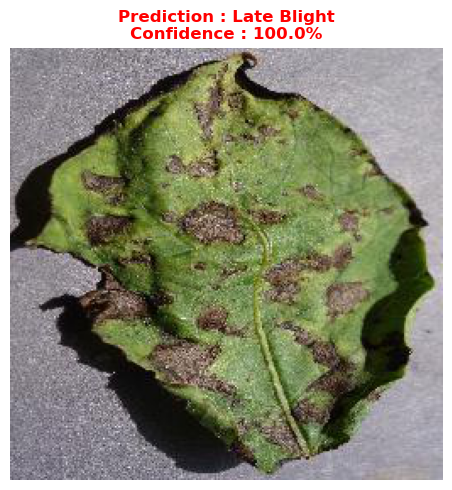


Disease    : Late Blight
Confidence : 100.0%
All class probabilities:
  Early Blight      0.0%  
  Late Blight     100.0%  ##############################
  Healthy           0.0%  


('Late Blight', 100.0)

In [32]:
import os

# Change class_index to:  0 = Early Blight,  1 = Late Blight,  2 = Healthy
# Change image_index to:  0 = first image,   1 = second image,  etc.

class_index = 0    # 0, 1, or 2
image_index = 0    # any number

folder    = os.path.join(DATASET_DIR, CLASSES[class_index])
all_imgs  = os.listdir(folder)
img_path  = os.path.join(folder, all_imgs[image_index])

print(f"Class : {CLASS_NAMES[class_index]}")
print(f"Image : {img_path}")
predict_disease(img_path)

Using image: PlantVillage\Potato___healthy\00fc2ee5-729f-4757-8aeb-65c3355874f2___RS_HL 1864.JPG


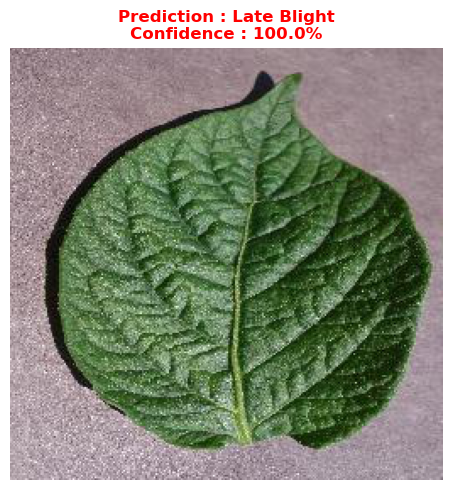


Disease    : Late Blight
Confidence : 100.0%
All class probabilities:
  Early Blight      0.0%  
  Late Blight     100.0%  ##############################
  Healthy           0.0%  


('Late Blight', 100.0)

In [33]:
# Fix 1: Import keras_image
from tensorflow.keras.preprocessing import image as keras_image

# Fix 2: Use a POTATO image (not pepper!)
import os

# Auto-pick a real potato image from your dataset
cls      = "Potato___healthy"
folder   = os.path.join(DATASET_DIR, cls)
img_file = os.listdir(folder)[0]
img_path = os.path.join(folder, img_file)

print(f"Using image: {img_path}")
predict_disease(img_path)